In [2]:
import os
import sys

# Set up project path
project_root = os.path.abspath('../')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Force reload of modules to ensure fresh imports
import importlib
if 'src.utils.data_loader' in sys.modules:
    del sys.modules['src.utils.data_loader']
if 'src.utils' in sys.modules:
    del sys.modules['src.utils']
if 'src' in sys.modules:
    del sys.modules['src']

print(f"Project Root: {project_root}")

Project Root: /Users/gayathri/Documents/SJSU/255/HybridReco


## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.data_loader import DataLoader
from src.algorithms.collaborative_filtering import CollaborativeFiltering
from src.utils.evaluation_metrics import EvaluationMetrics

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Prepare Data

In [11]:
# Load data files
users_path = os.path.join(project_root, 'data/users.csv')
products_path = os.path.join(project_root, 'data/products.csv')
transactions_path = os.path.join(project_root, 'data/transactions.csv')

print(f"Loading data files...")
users_df = DataLoader.load_users(users_path)
products_df = DataLoader.load_products(products_path)
transactions_df = DataLoader.load_transactions(transactions_path)

print(f"✓ Users: {len(users_df)}")
print(f"✓ Products: {len(products_df)}")
print(f"✓ Transactions: {len(transactions_df)}")

# Create interactions
interactions_df = DataLoader.create_user_item_interactions(transactions_df)
print(f"✓ Created {len(interactions_df)} interactions")
print(f"\nUsers: {interactions_df['user_id'].nunique()}")
print(f"Items: {interactions_df['item_id'].nunique()}")

Loading data files...
✓ Users: 6
✓ Products: 8
✓ Transactions: 29
✓ Created 28 interactions

Users: 6
Items: 8


## 2. Train-Test Split

In [19]:
# Split data using leave-one-out strategy per user for better evaluation
# This ensures each user appears in both train and test sets
train_list = []
test_list = []

for user_id in interactions_df['user_id'].unique():
    user_interactions = interactions_df[interactions_df['user_id'] == user_id].reset_index(drop=True)
    n_interactions = len(user_interactions)
    
    if n_interactions > 1:
        # Leave one item out for testing
        test_sample = user_interactions.sample(n=1, random_state=42)
        test_idx = test_sample.index[0]
        
        # Append all except test item to train
        train_list.append(user_interactions.drop(test_idx))
        test_list.append(test_sample)

train_df = pd.concat(train_list, ignore_index=True)
test_df = pd.concat(test_list, ignore_index=True) if test_list else pd.DataFrame()

print(f"Training set: {len(train_df)} interactions ({train_df['user_id'].nunique()} users)")
print(f"Test set: {len(test_df)} interactions ({test_df['user_id'].nunique()} users)")
print(f"All users present in both train and test? {set(test_df['user_id'].unique()).issubset(set(train_df['user_id'].unique()))}")

Training set: 22 interactions (6 users)
Test set: 6 interactions (6 users)
All users present in both train and test? True


## 3. Initialize and Train CF Model

In [20]:
# Train CF model
cf_model = CollaborativeFiltering(n_factors=50)
cf_model.fit(train_df)

print("✓ CF Model trained")
print(f"  User factors: {cf_model.user_factors.shape if cf_model.user_factors is not None else 'None'}")
print(f"  Item factors: {cf_model.item_factors.shape if cf_model.item_factors is not None else 'None'}")

✓ CF Model trained
  User factors: (6, 5)
  Item factors: (8, 5)


## 4. Generate Recommendations

In [21]:
# Generate recommendations for sample users
sample_users = interactions_df['user_id'].unique()[:3]  # Get first 3 users

print("Sample Recommendations from CF Model:")
for user_id in sample_users:
    # Get items user already purchased (to exclude from recommendations)
    purchased_items = set(interactions_df[interactions_df['user_id'] == user_id]['item_id'].values)
    
    # Get recommendations
    recs = cf_model.recommend(user_id, n_items=5, exclude_items=list(purchased_items))
    
    if recs:
        print(f"\nUser {user_id} (already owns: {len(purchased_items)} items):")
        print(f"  Top Recommendations:")
        for rank, (item_id, score) in enumerate(recs, 1):
            product_info = products_df[products_df['product_id'] == item_id]
            if not product_info.empty:
                name = product_info.iloc[0]['product_name']
                print(f"    {rank}. {item_id} - {name} (score: {score:.4f})")
    else:
        print(f"\nUser {user_id}: No new recommendations available")

Sample Recommendations from CF Model:

User U1 (already owns: 6 items):
  Top Recommendations:
    1. P8 - Notebook (Paper) (score: 1.1072)
    2. P6 - Laptop Sleeve (score: 1.0000)

User U2 (already owns: 5 items):
  Top Recommendations:
    1. P7 - Headphones (score: 1.0315)
    2. P8 - Notebook (Paper) (score: 1.0097)
    3. P2 - Coffee Filters (score: 1.0003)

User U3 (already owns: 5 items):
  Top Recommendations:
    1. P3 - Ceramic Mug (score: 1.0000)
    2. P6 - Laptop Sleeve (score: 1.0000)
    3. P8 - Notebook (Paper) (score: 1.0000)


## 5. Evaluate Model

Evaluating on 6 test users
  User U1: P@5=0.333, R@5=1.000, F1@5=0.500
  User U2: P@5=0.250, R@5=1.000, F1@5=0.400
  User U3: P@5=0.250, R@5=1.000, F1@5=0.400
  User U4: P@5=0.200, R@5=1.000, F1@5=0.333
  User U5: P@5=0.200, R@5=1.000, F1@5=0.333
  User U6: P@5=0.200, R@5=1.000, F1@5=0.333

CF Model Evaluation Results:
  Mean Precision@5: 0.2389
  Mean Recall@5: 1.0000
  Mean F1@5: 0.3833


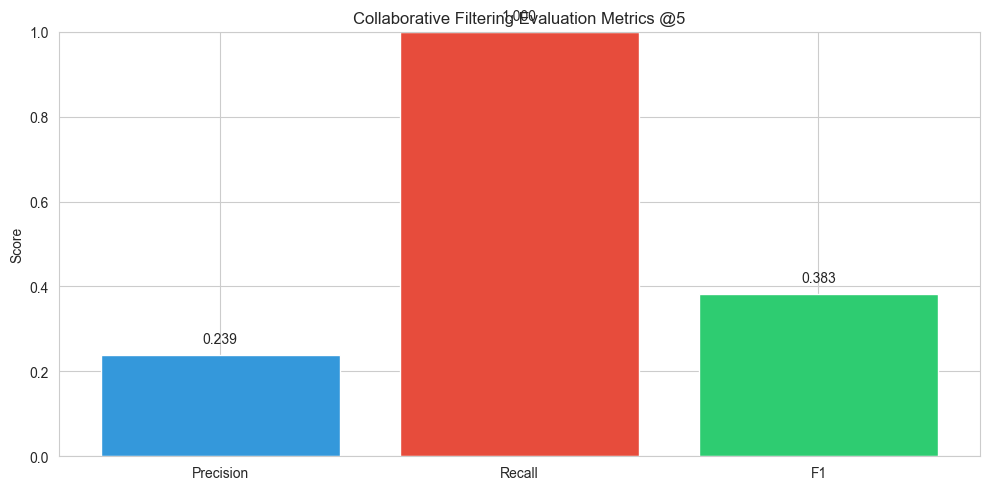

In [22]:
# Evaluate CF model with proper train-test split
precision_scores = []
recall_scores = []
f1_scores = []

sample_test_users = test_df['user_id'].unique()

print(f"Evaluating on {len(sample_test_users)} test users")

for user_id in sample_test_users:
    # Get ground truth (items user interacted with in test set)
    ground_truth = set(test_df[test_df['user_id'] == user_id]['item_id'].values)
    
    # Get items user saw in training (to exclude from recommendations)
    train_items = set(train_df[train_df['user_id'] == user_id]['item_id'].values)
    
    if len(ground_truth) == 0:
        continue
    
    # Get recommendations (exclude training items)
    recs = cf_model.recommend(user_id, n_items=10, exclude_items=list(train_items))
    rec_items = [item_id for item_id, _ in recs] if recs else []
    
    # Calculate metrics
    precision = EvaluationMetrics.precision_at_k(rec_items[:5], ground_truth, k=5)
    recall = EvaluationMetrics.recall_at_k(rec_items[:5], ground_truth, k=5)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    
    print(f"  User {user_id}: P@5={precision:.3f}, R@5={recall:.3f}, F1@5={f1:.3f}")

# Print results
if precision_scores:
    print(f"\nCF Model Evaluation Results:")
    print(f"  Mean Precision@5: {np.mean(precision_scores):.4f}")
    print(f"  Mean Recall@5: {np.mean(recall_scores):.4f}")
    print(f"  Mean F1@5: {np.mean(f1_scores):.4f}")
    
    # Plot evaluation
    fig, ax = plt.subplots(figsize=(10, 5))
    
    results = {
        'Precision': np.mean(precision_scores),
        'Recall': np.mean(recall_scores),
        'F1': np.mean(f1_scores)
    }
    
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    bars = ax.bar(list(results.keys()), list(results.values()), color=colors)
    ax.set_ylabel('Score')
    ax.set_title('Collaborative Filtering Evaluation Metrics @5')
    ax.set_ylim((0, 1))
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ No evaluation data available")

## 6. Analyze Similar Items

In [23]:
# Get similar items for a sample product
sample_item_id = 'P1'

print(f"\nFinding items similar to {sample_item_id}:")
product_name = products_df[products_df['product_id'] == sample_item_id]['product_name'].values
if len(product_name) > 0:
    print(f"  ({product_name[0]})")

# Note: get_similar_items expects numeric item_id, need to map string to index
# For now, we'll show the concept
if cf_model.item_id_map and sample_item_id in cf_model.reverse_item_map:
    similar_items = cf_model.get_similar_items(sample_item_id, n_items=5)
    if similar_items:
        for item_id, similarity in similar_items:
            product_info = products_df[products_df['product_id'] == item_id]
            if not product_info.empty:
                name = product_info.iloc[0]['product_name']
                print(f"  {item_id} - {name} (similarity: {similarity:.4f})")
    else:
        print(f"  No similar items found")
else:
    print(f"  Item not found in model")


Finding items similar to P1:
  (Coffee Beans)
  Item not found in model


## 7. Visualize Model Performance

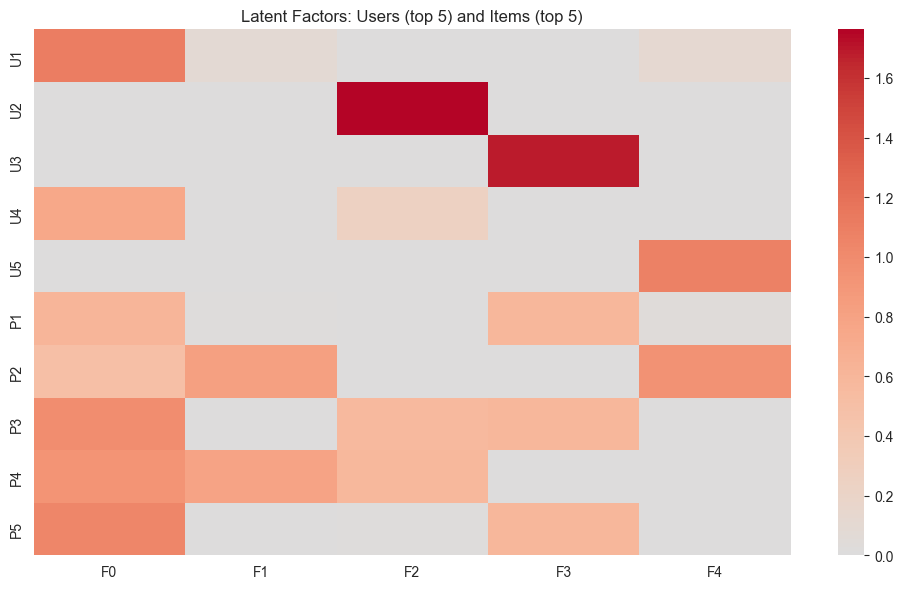

Latent factors visualization complete


In [24]:
# Visualize latent factors
if cf_model.user_factors is not None and cf_model.item_factors is not None:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Get user and item matrices - limit to first 5 of each
    n_show_users = min(5, cf_model.user_factors.shape[0])
    n_show_items = min(5, cf_model.item_factors.shape[0])
    n_show_factors = min(10, cf_model.user_factors.shape[1])
    
    user_factors_viz = cf_model.user_factors[:n_show_users, :n_show_factors]
    item_factors_viz = cf_model.item_factors[:n_show_items, :n_show_factors]
    
    # Combine for visualization
    factors_viz = np.vstack([user_factors_viz, item_factors_viz])
    labels = [f'U{i+1}' for i in range(n_show_users)] + [f'P{i+1}' for i in range(n_show_items)]
    
    sns.heatmap(factors_viz, cmap='coolwarm', center=0, annot=False, 
                xticklabels=[f'F{i}' for i in range(n_show_factors)],
                yticklabels=labels)
    ax.set_title('Latent Factors: Users (top 5) and Items (top 5)')
    plt.tight_layout()
    plt.show()
    
    print("Latent factors visualization complete")
else:
    print("Model factors not available")

## Summary

**Collaborative Filtering Results:**
- Matrix factorization using NMF
- User and item latent factors computed
- Personalized recommendations generated
- Performance evaluated using Precision@K and Recall@K
- Ready for hybrid model combination